In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("exchange_rate.csv")

df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   str    
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), str(1)
memory usage: 118.7 KB


In [7]:
df.isnull().sum()

date       0
Ex_rate    0
dtype: int64

### Convert Date Column into Datetime

In [8]:
df['date'] = pd.to_datetime(
    df['date'],
    dayfirst=True
)

df.head()

,date,Ex_rate
0,1990-01-01,0.7855
1,1990-01-02,0.7818
2,1990-01-03,0.7867
3,1990-01-04,0.7860
4,1990-01-05,0.7849


### Set Date Column as Index

In [9]:
df.set_index(
    'date',
    inplace=True
)

df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


### Plot Time Series

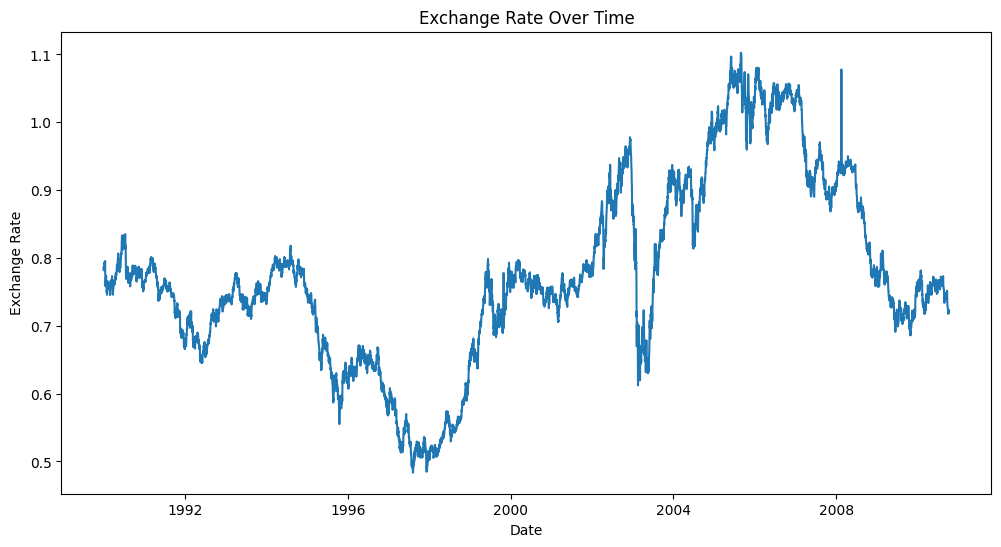

In [10]:
plt.figure(figsize=(12,6))

plt.plot(
    df['Ex_rate']
)

plt.title("Exchange Rate Over Time")

plt.xlabel("Date")

plt.ylabel("Exchange Rate")

plt.show()

### Check Missing Values

In [11]:
df.isnull().sum()

Ex_rate    0
dtype: int64

### Summary Statistics

In [12]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


### Distribution Plot

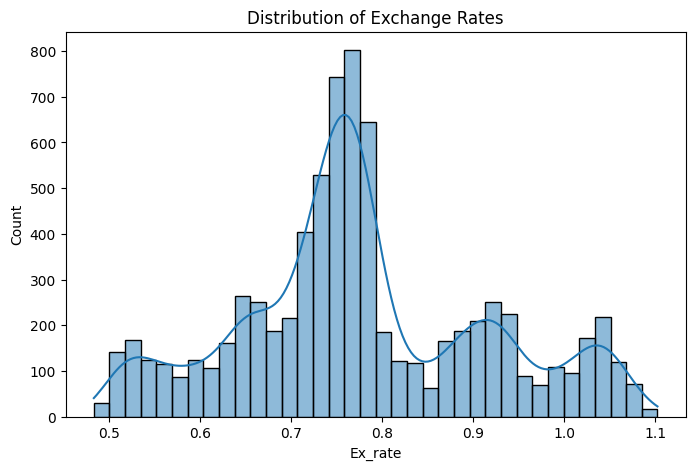

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Ex_rate'],
    kde=True
)

plt.title("Distribution of Exchange Rates")

plt.show()

### Rolling Mean and Rolling Std

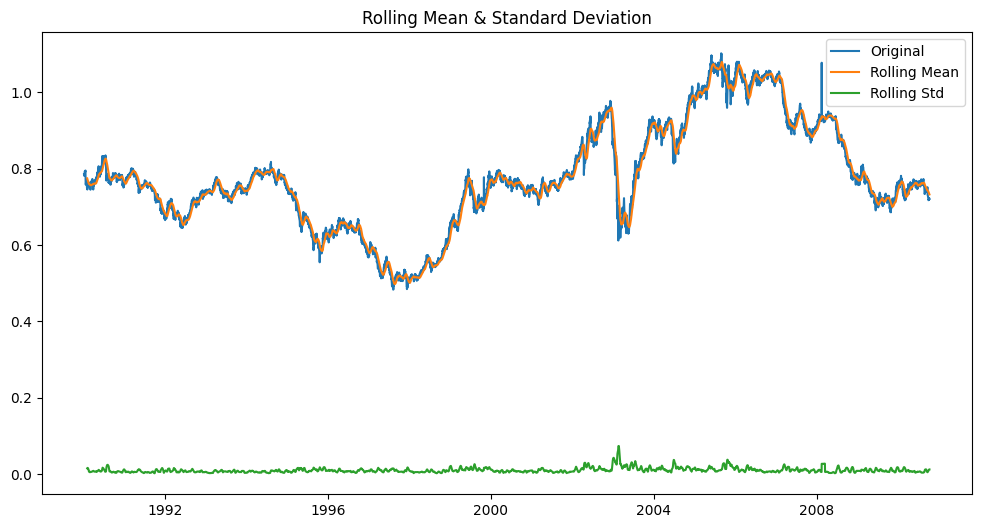

In [14]:
rolling_mean = df['Ex_rate'].rolling(window=30).mean()

rolling_std = df['Ex_rate'].rolling(window=30).std()

plt.figure(figsize=(12,6))

plt.plot(df['Ex_rate'], label='Original')

plt.plot(rolling_mean, label='Rolling Mean')

plt.plot(rolling_std, label='Rolling Std')

plt.legend()

plt.title("Rolling Mean & Standard Deviation")

plt.show()

### Import ACF and PACF Tools

In [15]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

### ACF Plot

<Figure size 1000x500 with 0 Axes>

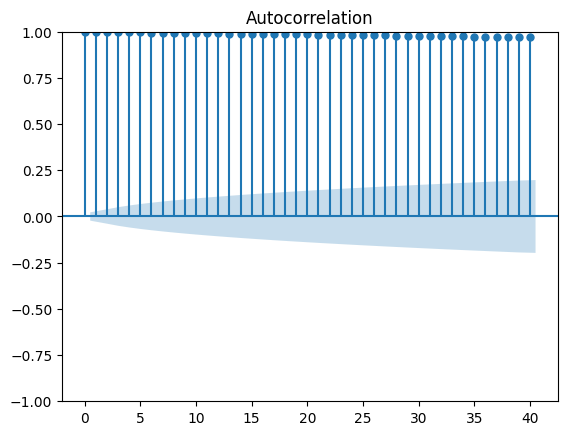

In [16]:
plt.figure(figsize=(10,5))

plot_acf(
    df['Ex_rate'],
    lags=40
)

plt.show()

### PACF Plot

<Figure size 1000x500 with 0 Axes>

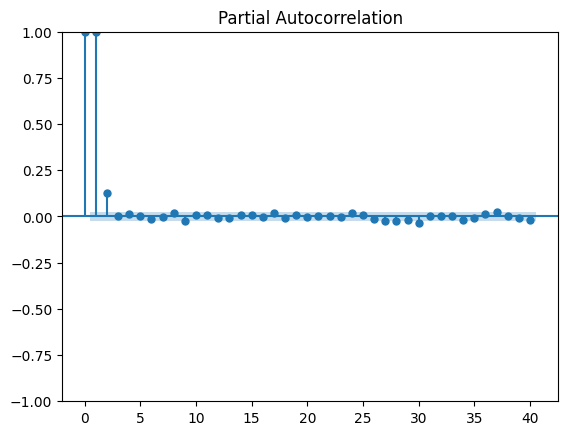

In [17]:
plt.figure(figsize=(10,5))

plot_pacf(
    df['Ex_rate'],
    lags=40
)

plt.show()

### Set Frequency

In [22]:
df = df.asfreq('D')

### Train-Test Split for Time Series

In [23]:
train = df.iloc[:int(len(df)*0.8)]

test = df.iloc[int(len(df)*0.8):]

### Import ARIMA Model

In [24]:
from statsmodels.tsa.arima.model import ARIMA

### Build ARIMA Model

In [25]:
arima_model = ARIMA(
    train['Ex_rate'],
    order=(1,1,1)
)

arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Wed, 20 May 2026   AIC                         -45432.092
Time:                        22:36:01   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

### ARIMA Residual Analysis

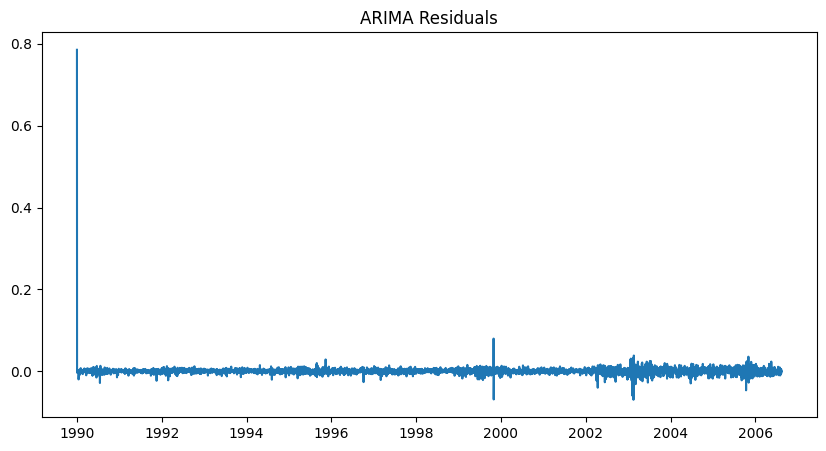

In [26]:
residuals = arima_fit.resid

plt.figure(figsize=(10,5))

plt.plot(residuals)

plt.title("ARIMA Residuals")

plt.show()

### Residual Distribution

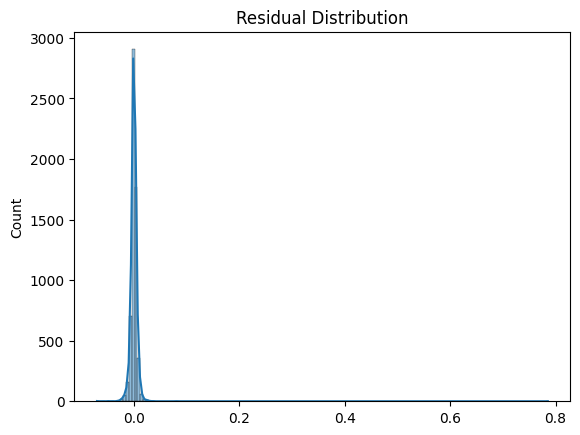

In [27]:
sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

### Forecast Using ARIMA

In [28]:
forecast = arima_fit.forecast(
    steps=len(test)
)

forecast.head()

2006-08-15    1.023685
2006-08-16    1.023606
2006-08-17    1.023653
2006-08-18    1.023625
2006-08-19    1.023642
Freq: D, Name: predicted_mean, dtype: float64

### Visualize ARIMA Forecast vs Actual

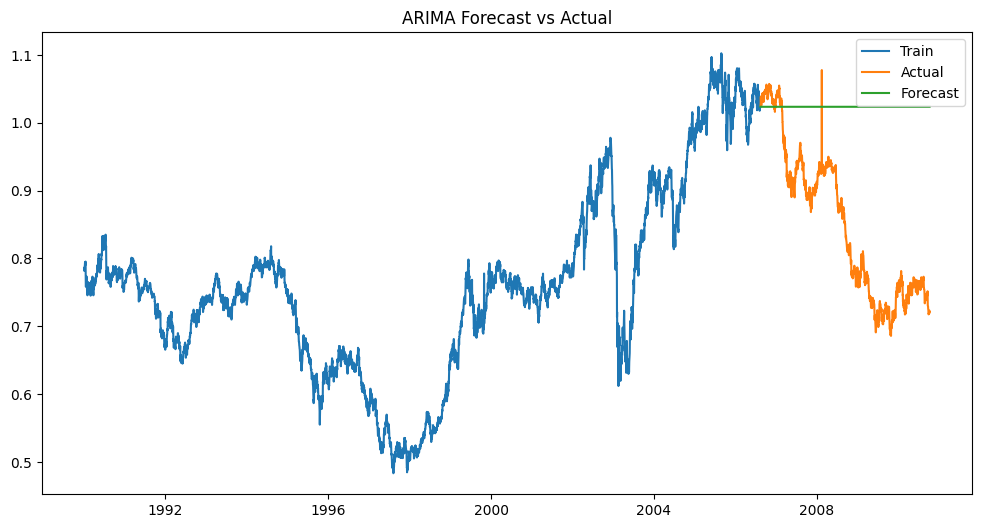

In [29]:
plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train['Ex_rate'],
    label='Train'
)

plt.plot(
    test.index,
    test['Ex_rate'],
    label='Actual'
)

plt.plot(
    test.index,
    forecast,
    label='Forecast'
)

plt.legend()

plt.title("ARIMA Forecast vs Actual")

plt.show()

### Import Exponential Smoothing

In [30]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

### Build Exponential Smoothing Model

In [31]:
exp_model = ExponentialSmoothing(
    train['Ex_rate'],
    trend='add'
)

exp_fit = exp_model.fit()

print(exp_fit.params)

{'smoothing_level': np.float64(0.9428890002269014), 'smoothing_trend': np.float64(0.0), 'smoothing_seasonal': np.float64(nan), 'damping_trend': nan, 'initial_level': np.float64(0.7852625122421487), 'initial_trend': np.float64(3.9251526039802166e-05), 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


### Forecast Using Exponential Smoothing

In [32]:
exp_forecast = exp_fit.forecast(
    len(test)
)

exp_forecast.head()

2006-08-15    1.023582
2006-08-16    1.023621
2006-08-17    1.023661
2006-08-18    1.023700
2006-08-19    1.023739
Freq: D, dtype: float64

### Visualize Exponential Smoothing Forecast

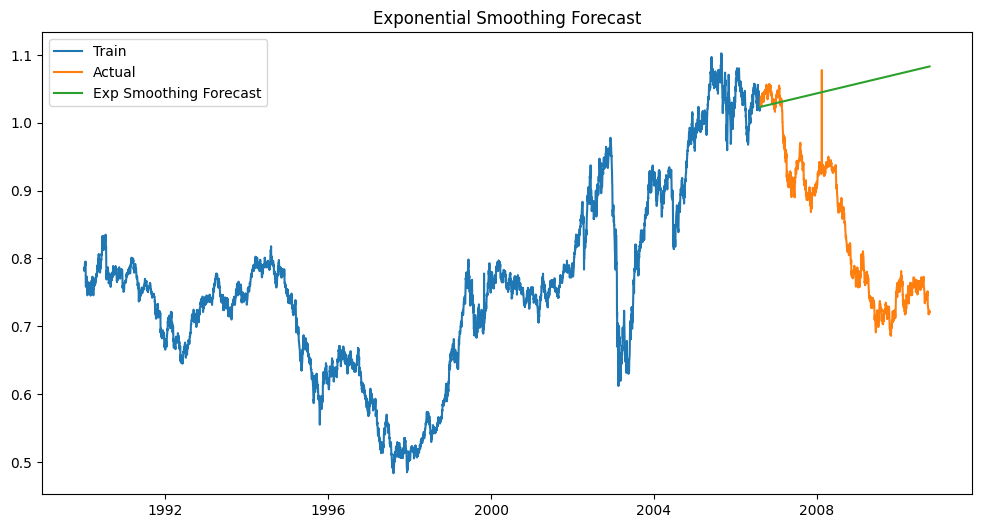

In [33]:
plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train['Ex_rate'],
    label='Train'
)

plt.plot(
    test.index,
    test['Ex_rate'],
    label='Actual'
)

plt.plot(
    test.index,
    exp_forecast,
    label='Exp Smoothing Forecast'
)

plt.legend()

plt.title("Exponential Smoothing Forecast")

plt.show()

### Import Evaluation Metrics

In [34]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

### Evaluate ARIMA Model

In [35]:
arima_mae = mean_absolute_error(
    test['Ex_rate'],
    forecast
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test['Ex_rate'],
        forecast
    )
)

arima_mape = np.mean(
    np.abs(
        (test['Ex_rate'] - forecast)
        / test['Ex_rate']
    )
) * 100

print("ARIMA MAE:", arima_mae)

print("ARIMA RMSE:", arima_rmse)

print("ARIMA MAPE:", arima_mape)

ARIMA MAE: 0.17770970449121345
ARIMA RMSE: 0.2054366965966928
ARIMA MAPE: 22.797966173811552


### Evaluate Exponential Smoothing Model

In [36]:
exp_mae = mean_absolute_error(
    test['Ex_rate'],
    exp_forecast
)

exp_rmse = np.sqrt(
    mean_squared_error(
        test['Ex_rate'],
        exp_forecast
    )
)

exp_mape = np.mean(
    np.abs(
        (test['Ex_rate'] - exp_forecast)
        / test['Ex_rate']
    )
) * 100

print("Exponential Smoothing MAE:", exp_mae)

print("Exponential Smoothing RMSE:", exp_rmse)

print("Exponential Smoothing MAPE:", exp_mape)

Exponential Smoothing MAE: 0.2065961926538986
Exponential Smoothing RMSE: 0.23910443338090956
Exponential Smoothing MAPE: 26.50866399299623


### Compare Model Performance

In [37]:
comparison = pd.DataFrame({
    'Model': [
        'ARIMA',
        'Exponential Smoothing'
    ],
    
    'MAE': [
        arima_mae,
        exp_mae
    ],
    
    'RMSE': [
        arima_rmse,
        exp_rmse
    ],
    
    'MAPE': [
        arima_mape,
        exp_mape
    ]
})

comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,0.177710,0.205437,22.797966
1,Exponential Smoothing,0.206596,0.239104,26.508664


### Visualize Model Comparison

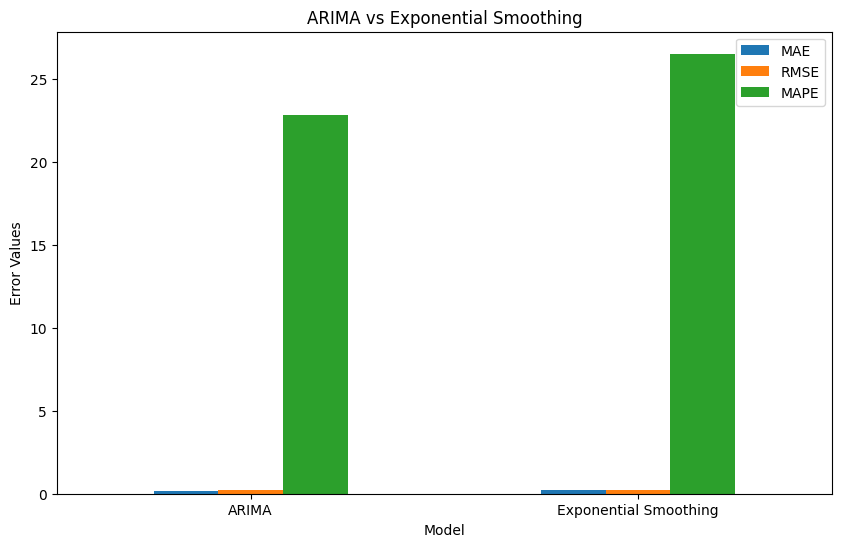

In [38]:
comparison.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("ARIMA vs Exponential Smoothing")

plt.ylabel("Error Values")

plt.xticks(rotation=0)

plt.show()

## Analysis of Models

##### ARIMA Advantages:
######  1. Captures autoregressive patterns
######  2. Good for stationary time series
######  3. Effective for short-term forecasting

##### ARIMA Limitations:
######  1. Requires parameter tuning (p,d,q)
######  2. Sensitive to non-stationary data
######  3. Complex for seasonal patterns

##### Exponential Smoothing Advantages:
######  1. Simple and easy to implement
######  2. Works well for trend-based data
######  3. Fast forecasting method

##### Exponential Smoothing Limitations:
###### 1. Less effective for highly complex series
###### 2. Sensitive to sudden fluctuations
###### 3. Limited long-term forecasting capability

# Conclusion

###### Both ARIMA and Exponential Smoothing are powerful forecasting techniques for time series analysis. ARIMA is suitable for capturing temporal dependencies, while Exponential Smoothing provides simpler and faster forecasting for trend-based data.

###### The final model selection should depend on forecasting accuracy, data characteristics, and business requirements.